In [ ]:
import tensorflow as tf
#step1: load dataset
minst=tf.keras.datasets.mnist
(x_train,y_train),(x_test,y_test)=minst.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("train images shape:",x_train.shape)
print("train labels shape:",y_train.shape)
print("test images shape:",x_test.shape)
print("test labels shape:",y_test.shape)

train images shape: (60000, 28, 28)
train labels shape: (60000,)
test images shape: (10000, 28, 28)
test labels shape: (10000,)


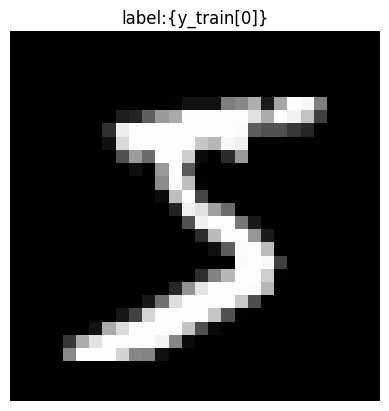

In [ ]:
import matplotlib.pyplot as plt
#plot first image
plt.imshow(x_train[0],cmap="grey")
plt.title("label:{y_train[0]}")
plt.axis("off")
plt.show()

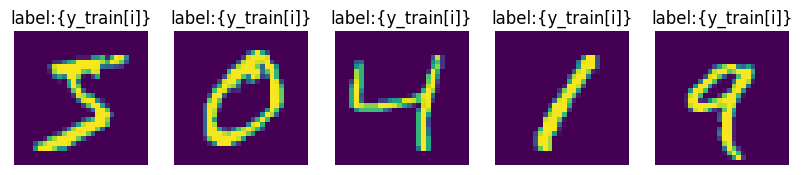

In [ ]:
#show first 5 images with label
plt.figure(figsize=(10,2))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(x_train[i])
  plt.title("label:{y_train[i]}")
  plt.axis("off")
plt.show()


In [ ]:
# step 2 normal size values(0 to 9)
train_images=x_train/255.0
test_images=x_test/255.0

In [ ]:
#step 3 add channel dimension ( important for cni)
train_images=train_images.reshape((60000,28,28,1))
test_images=test_images.reshape((10000,28,28,1))

In [ ]:
from tensorflow.keras import layers,models
model=models.Sequential([layers.Conv2D(16,(3,3),activation='relu',input_shape=(28,28,1)),
                         layers.MaxPooling2D((2,2)),
                         layers.Flatten(),
                         layers.Dense(32,activation='relu'),
                         layers.Dense(10,activation='softmax')])

In [ ]:
#step 4 Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
#step 5 train model
model.fit(train_images,y_train,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9866 - loss: 0.0453
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9893 - loss: 0.0355
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9905 - loss: 0.0298


In [ ]:
#step 7 test model
test_loss,test_acc=model.evaluate(test_images,y_test)
print("test acccuracy",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9802 - loss: 0.0663
test acccuracy 0.9801999926567078


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Original Label: 2
Predicted Label: 2


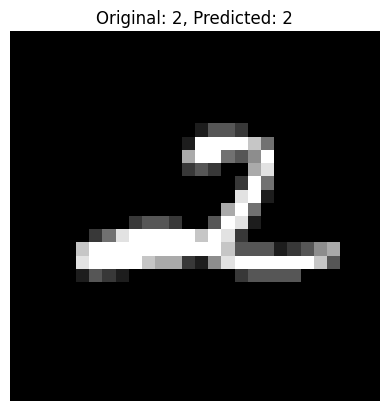

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Pick a random index
index = np.random.randint(0, len(test_images))

# Get image and label
sample_image = test_images[index]
true_label = y_test[index]

# Expand dimensions for model input
sample_image_input = np.expand_dims(sample_image, axis=0)

# Predict
prediction = model.predict(sample_image_input)    # gives probability from 0 to 9
predicted_label = np.argmax(prediction)           # gives the index of highest probability

# Print results
print("Original Label:", true_label)
print("Predicted Label:", predicted_label)

# Show the image
plt.imshow(sample_image.squeeze(), cmap='gray')
plt.title(f"Original: {true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nirmalsankalana/apple-leaf-disease-dataset")

print("Path to dataset files:", path)

100%|██████████| 361M/361M [00:07<00:00, 53.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nirmalsankalana/apple-leaf-disease-dataset/versions/2
